# Model 1 — TF-IDF + Cosine Similarity (Baseline)

**Goal:** Establish a non-contextual baseline. If our advanced models (Model 2 and 3) don't beat this, something is wrong.

### Approach
1. Fit a single `TfidfVectorizer` on **all text** (PAN + Quora, train split only) so both datasets share the same vocabulary
2. For each pair `(text_a, text_b)`, transform both into TF-IDF vectors and compute **cosine similarity**
3. Tune a similarity threshold on validation set to convert similarity → binary prediction
4. Evaluate on PAN test (external only) and Quora test

### Why this is a real baseline (not a toy)
- TF-IDF + cosine is exactly what most plagiarism systems used pre-2018
- Should crush exact copy-paste cases
- Should fail on heavy paraphrase/translation — exposing where Models 2 and 3 must improve

## 1. Setup

In [28]:
import sys, os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm.notebook import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROCESSED_DIR = Path('/content/drive/MyDrive/pan-processed')
RESULTS_DIR   = Path('results');         RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR    = Path('trained_models');  MODELS_DIR.mkdir(exist_ok=True)
RANDOM_STATE  = 42

# ── Inline data loader (no separate file needed) ──────────────────────
def load_pan():
    train = pd.read_csv(PROCESSED_DIR / 'pan_train.csv')
    val   = pd.read_csv(PROCESSED_DIR / 'pan_val.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'pan_test.csv')
    return train, val, test

def load_quora():
    train = pd.read_csv(PROCESSED_DIR / 'quora_train.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'quora_test.csv')
    return train, test

def get_pair_dataset(df, dataset, *, drop_no_source=True, drop_intrinsic=False):
    if dataset == 'pan':
        out = df.copy()
        if drop_intrinsic:
            out = out[out['corpus_type'] != 'intrinsic']
        if drop_no_source:
            out = out[(out['source_text'].notna()) & (out['source_text'] != 'NONE')]
        out = out.rename(columns={
            'suspicious_text': 'text_a',
            'source_text'    : 'text_b',
            'is_plagiarism'  : 'label',
        })
        return out[['text_a', 'text_b', 'label']].reset_index(drop=True)
    elif dataset == 'quora':
        out = df.rename(columns={
            'q1_clean'    : 'text_a',
            'q2_clean'    : 'text_b',
            'is_duplicate': 'label',
        })
        return out[['text_a', 'text_b', 'label']].reset_index(drop=True)
    raise ValueError(f"Unknown dataset: {dataset}")

print('Setup complete')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


## 2. Load data

In [29]:
import numpy as np
np.random.seed(42)

def build_pan_pairs(df_pan):
    # Positives — real plagiarism with valid source
    pos = df_pan[
        (df_pan['is_plagiarism'] == 1) &
        (df_pan['corpus_type']  == 'external') &
        (df_pan['source_text'].notna()) &
        (df_pan['source_text']  != 'NONE')
    ].copy()

    # Pool of all valid source passages
    src_pool = pos['source_text'].values

    # Negatives — pair non-plagiarism passages with random unrelated source
    neg = df_pan[df_pan['is_plagiarism'] == 0].copy()
    if len(neg) > 0:
        neg = neg[neg['corpus_type'] == 'external'].copy()
        neg['source_text'] = np.random.choice(src_pool, size=len(neg))

    out = pd.concat([pos, neg], ignore_index=True)
    out = out.rename(columns={
        'suspicious_text': 'text_a',
        'source_text'    : 'text_b',
        'is_plagiarism'  : 'label',
    })
    return out[['text_a', 'text_b', 'label', 'plagiarism_type', 'obfuscation']].reset_index(drop=True)


pan_train_pairs = build_pan_pairs(pan_train)
pan_val_pairs   = build_pan_pairs(pan_val)
pan_test_pairs  = build_pan_pairs(pan_test)

print('PAN pair counts (with negatives):')
for name, df in [('train', pan_train_pairs), ('val', pan_val_pairs), ('test', pan_test_pairs)]:
    pos = df['label'].sum()
    neg = len(df) - pos
    print(f'  {name:6s} | total={len(df):>6,d} | pos={pos:>5,d} | neg={neg:>5,d}')

PAN pair counts (with negatives):
  train  | total=42,811 | pos=35,218 | neg=7,593
  val    | total= 8,378 | pos=6,755 | neg=1,623
  test   | total= 9,276 | pos=7,647 | neg=1,629


## 3. Fit TF-IDF vectorizer

Fit on **combined train text** (both columns), so vocabulary covers both PAN and Quora vocabulary. Using sublinear TF scaling (1+log(tf)) since long PAN passages would otherwise dominate.

In [30]:
# Concatenate both columns to feed the vectorizer
all_train_text = pd.concat([combined_train['text_a'], combined_train['text_b']], ignore_index=True)
all_train_text = all_train_text.fillna('').astype(str)

print(f'Fitting TF-IDF on {len(all_train_text):,} text segments…')

vectorizer = TfidfVectorizer(
    ngram_range    = (1, 2),       # unigrams + bigrams
    max_features   = 100_000,
    min_df         = 3,            # ignore terms appearing in <3 docs
    max_df         = 0.95,         # ignore terms in >95% of docs
    sublinear_tf   = True,         # 1 + log(tf) — better for long passages
    stop_words     = 'english',
    strip_accents  = 'unicode',
    lowercase      = True,
    norm           = 'l2',
)
vectorizer.fit(all_train_text)
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')

Fitting TF-IDF on 652,384 text segments…
Vocabulary size: 100,000


## 4. Cosine similarity scorer

In [31]:
def score_pairs(df, vectorizer, batch_size=5000):
    """
    Compute cosine similarity for each (text_a, text_b) pair.
    Returns array of similarities in [0, 1].
    Batched to avoid memory blowup on large datasets.
    """
    sims = np.zeros(len(df), dtype=np.float32)
    a = df['text_a'].fillna('').astype(str).values
    b = df['text_b'].fillna('').astype(str).values

    for start in tqdm(range(0, len(df), batch_size), desc='Scoring'):
        end = min(start + batch_size, len(df))
        Va = vectorizer.transform(a[start:end])
        Vb = vectorizer.transform(b[start:end])
        # Row-wise cosine: dot(Va_i, Vb_i) since both are L2-normalized
        sims[start:end] = np.asarray(Va.multiply(Vb).sum(axis=1)).ravel()

    return sims

## 5. Score validation set & tune threshold

We pick the threshold that maximizes **F1** on the combined validation set.

Tuning thresholds on val sets...



Scoring:   0%|          | 0/2 [00:00<?, ?it/s]

Scoring:   0%|          | 0/7 [00:00<?, ?it/s]

  PAN      → best threshold = 0.05  (val F1 = 0.9654)
  Quora    → best threshold = 0.17  (val F1 = 0.6045)


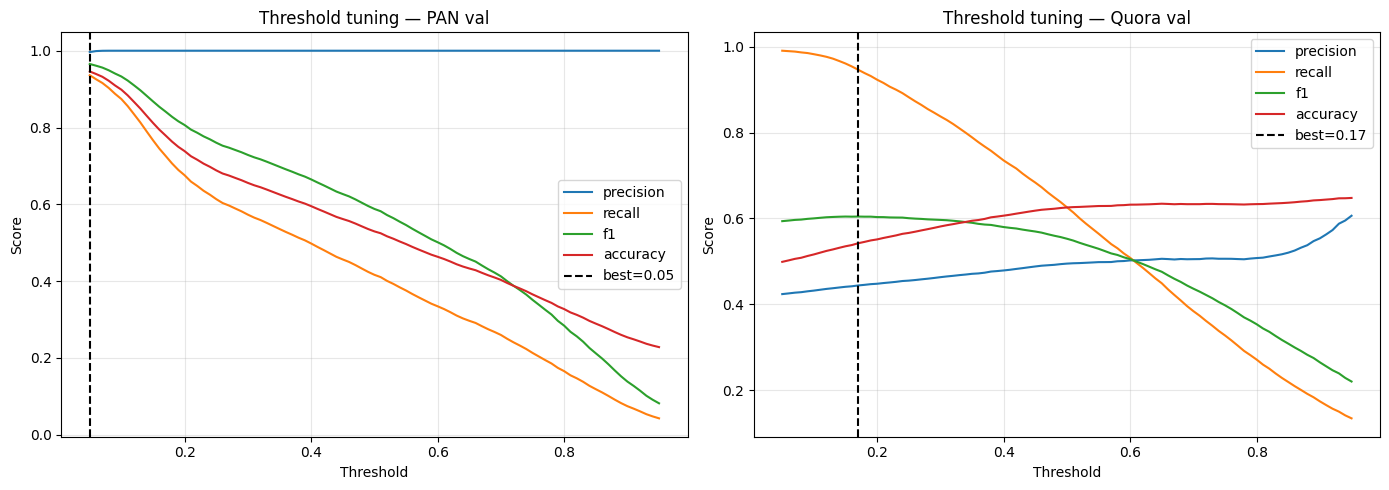


Final thresholds → PAN: 0.05   Quora: 0.17


In [32]:
def find_best_threshold(sims, labels, name):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_f1, best_t = 0, 0.5
    rows = []
    for t in thresholds:
        preds = (sims >= t).astype(int)
        f1  = f1_score(labels, preds, zero_division=0)
        acc = accuracy_score(labels, preds)
        pre = precision_score(labels, preds, zero_division=0)
        rec = recall_score(labels, preds, zero_division=0)
        rows.append({'threshold': t, 'f1': f1, 'accuracy': acc,
                     'precision': pre, 'recall': rec})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  {name:8s} → best threshold = {best_t:.2f}  (val F1 = {best_f1:.4f})')
    return best_t, pd.DataFrame(rows)

print('Tuning thresholds on val sets...')
print()

pan_val_sims = score_pairs(pan_val_pairs, vectorizer)
q_val_sims   = score_pairs(q_val_pairs,   vectorizer)

PAN_THRESHOLD, pan_thresh_df = find_best_threshold(
    pan_val_sims, pan_val_pairs['label'].values, 'PAN')

Q_THRESHOLD, q_thresh_df = find_best_threshold(
    q_val_sims, q_val_pairs['label'].values, 'Quora')

# Plot threshold curves for both datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, thresh_df, best_t, name in [
    (axes[0], pan_thresh_df,   PAN_THRESHOLD, 'PAN val'),
    (axes[1], q_thresh_df,     Q_THRESHOLD,   'Quora val'),
]:
    for col, color in [('precision','tab:blue'), ('recall','tab:orange'),
                       ('f1','tab:green'), ('accuracy','tab:red')]:
        ax.plot(thresh_df['threshold'], thresh_df[col], label=col, color=color)
    ax.axvline(best_t, color='black', linestyle='--', label=f'best={best_t:.2f}')
    ax.set_title(f'Threshold tuning — {name}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model1_threshold_tuning.png', dpi=120)
plt.show()

print(f'\nFinal thresholds → PAN: {PAN_THRESHOLD:.2f}   Quora: {Q_THRESHOLD:.2f}')

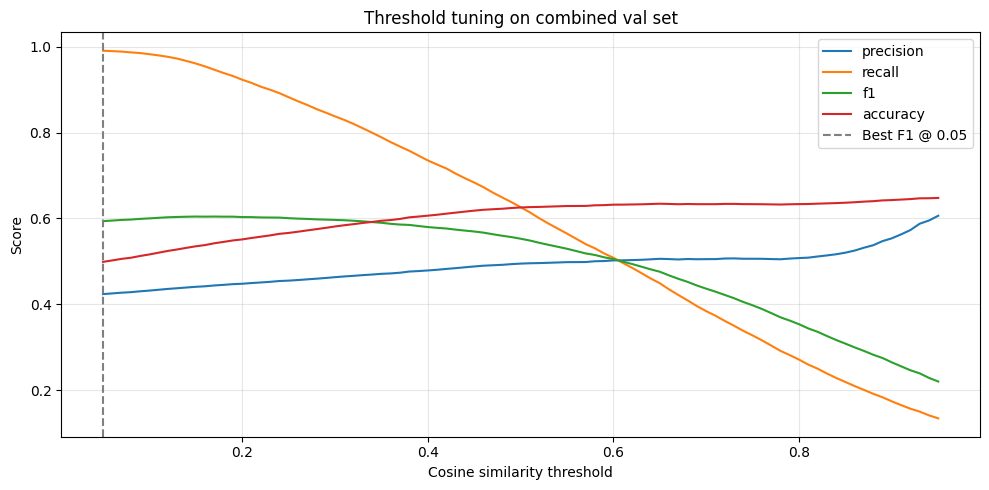

In [33]:
# Plot threshold vs metrics
fig, ax = plt.subplots(figsize=(10, 5))
for col, color in [('precision', 'tab:blue'), ('recall', 'tab:orange'),
                    ('f1', 'tab:green'), ('accuracy', 'tab:red')]:
    ax.plot(thresh_df['threshold'], thresh_df[col], label=col, color=color)
ax.axvline(BEST_THRESHOLD, color='gray', linestyle='--', label=f'Best F1 @ {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Cosine similarity threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold tuning on combined val set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model1_threshold_tuning.png', dpi=120)
plt.show()

## 6. Evaluation function

In [34]:
def evaluate(df_pairs, name, vectorizer, threshold):
    sims  = score_pairs(df_pairs, vectorizer)
    y     = df_pairs['label'].values
    preds = (sims >= threshold).astype(int)

    metrics = {
        'dataset'  : name,
        'n'        : len(df_pairs),
        'accuracy' : accuracy_score(y, preds),
        'precision': precision_score(y, preds, zero_division=0),
        'recall'   : recall_score(y, preds, zero_division=0),
        'f1'       : f1_score(y, preds, zero_division=0),
        'roc_auc'  : roc_auc_score(y, sims) if len(np.unique(y)) > 1 else float('nan'),
    }
    print(f'\n── {name} ─────────────────────────────────')
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f'  {k:9s}: {v:.4f}')
        else:
            print(f'  {k:9s}: {v}')
    print(f'\n{classification_report(y, preds, target_names=["non-plag", "plagiarism"], zero_division=0)}')
    return metrics, sims, preds

## 7. Evaluate on PAN test and Quora test

In [35]:
pan_metrics, pan_sims, pan_preds = evaluate(pan_test_pairs, 'PAN test',   vectorizer, PAN_THRESHOLD)
q_metrics,   q_sims,   q_preds   = evaluate(q_test_pairs,   'Quora test', vectorizer, Q_THRESHOLD)

results_df = pd.DataFrame([
    {**pan_metrics, 'threshold': PAN_THRESHOLD},
    {**q_metrics,   'threshold': Q_THRESHOLD},
])
results_df.to_csv(RESULTS_DIR / 'model1_metrics.csv', index=False)
print('\n── Final Results ──')
print(results_df.to_string(index=False))

Scoring:   0%|          | 0/2 [00:00<?, ?it/s]


── PAN test ─────────────────────────────────
  dataset  : PAN test
  n        : 9276
  accuracy : 0.9463
  precision: 0.9972
  recall   : 0.9375
  f1       : 0.9664
  roc_auc  : 0.9822

              precision    recall  f1-score   support

    non-plag       0.77      0.99      0.87      1629
  plagiarism       1.00      0.94      0.97      7647

    accuracy                           0.95      9276
   macro avg       0.88      0.96      0.92      9276
weighted avg       0.96      0.95      0.95      9276



Scoring:   0%|          | 0/17 [00:00<?, ?it/s]


── Quora test ─────────────────────────────────
  dataset  : Quora test
  n        : 80827
  accuracy : 0.5443
  precision: 0.4450
  recall   : 0.9446
  f1       : 0.6049
  roc_auc  : 0.6822

              precision    recall  f1-score   support

    non-plag       0.91      0.31      0.46     50972
  plagiarism       0.44      0.94      0.60     29855

    accuracy                           0.54     80827
   macro avg       0.68      0.63      0.53     80827
weighted avg       0.74      0.54      0.51     80827


── Final Results ──
   dataset     n  accuracy  precision   recall       f1  roc_auc  threshold
  PAN test  9276  0.946313   0.997218 0.937492 0.966433 0.982202       0.05
Quora test 80827  0.544311   0.444956 0.944565 0.604943 0.682224       0.17


## 8. Confusion matrices

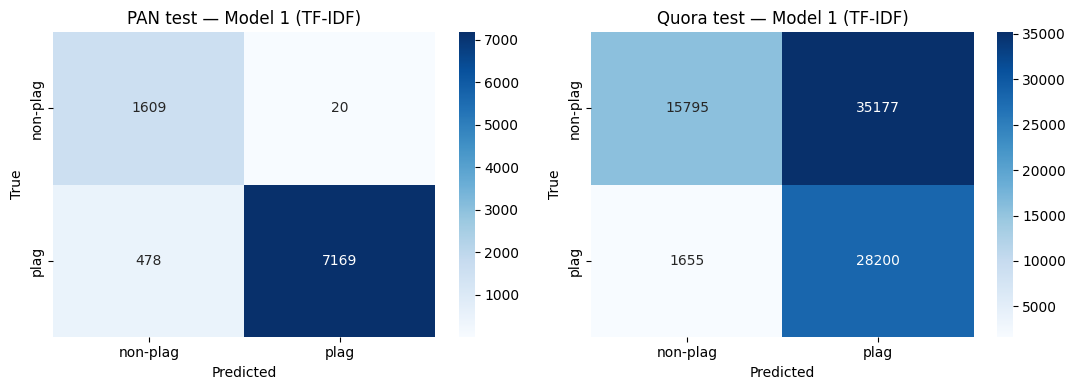

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_true, y_pred) in zip(axes, [
    ('PAN test',   pan_test_pairs['label'].values, pan_preds),
    ('Quora test', q_test_pairs['label'].values,   q_preds),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['non-plag', 'plag'],
                yticklabels=['non-plag', 'plag'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Model 1 (TF-IDF)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model1_confusion_matrices.png', dpi=120)
plt.show()

## 9. ROC curves

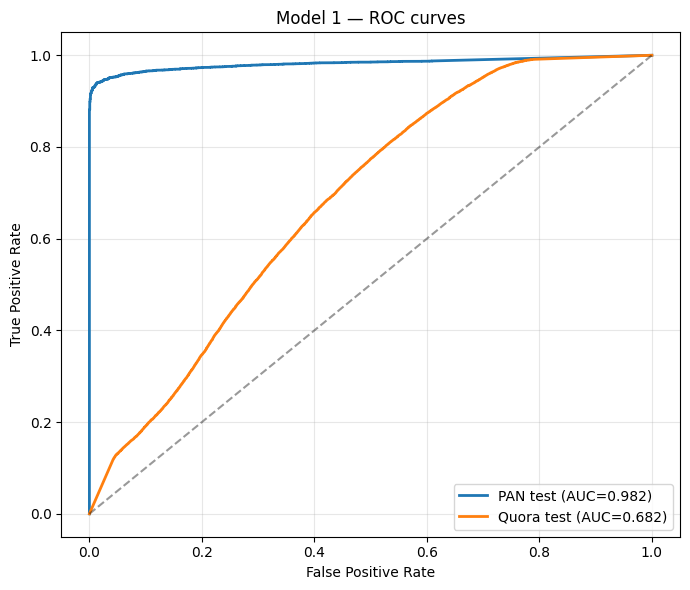

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
for label, sims, y_true in [
    (f'PAN test (AUC={pan_metrics["roc_auc"]:.3f})',   pan_sims, pan_test_pairs['label'].values),
    (f'Quora test (AUC={q_metrics["roc_auc"]:.3f})',   q_sims,   q_test_pairs['label'].values),
]:
    fpr, tpr, _ = roc_curve(y_true, sims)
    ax.plot(fpr, tpr, label=label, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 — ROC curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model1_roc.png', dpi=120)
plt.show()

## 10. Per-obfuscation breakdown (PAN test)

This is the most informative result — it shows where TF-IDF starts to fail and where Models 2 and 3 should improve.

── By plagiarism_type ──
                  total     pos  accuracy  avg_sim
plagiarism_type                                   
artificial       5722.0  5722.0     0.997    0.492
none             1629.0     0.0     0.988    0.010
simulated        1066.0  1066.0     0.991    0.530
translation       859.0   859.0     0.476    0.056

── By obfuscation level (positive cases only) ──
              total  detected  recall  avg_sim
obfuscation                                   
NONE         1925.0    1465.0   0.761    0.319
high         2765.0    2748.0   0.994    0.339
low          2865.0    2864.0   1.000    0.624
none           92.0      92.0   1.000    1.000


/tmp/ipykernel_334/2021764886.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pan_test_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
/tmp/ipykernel_334/2021764886.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({


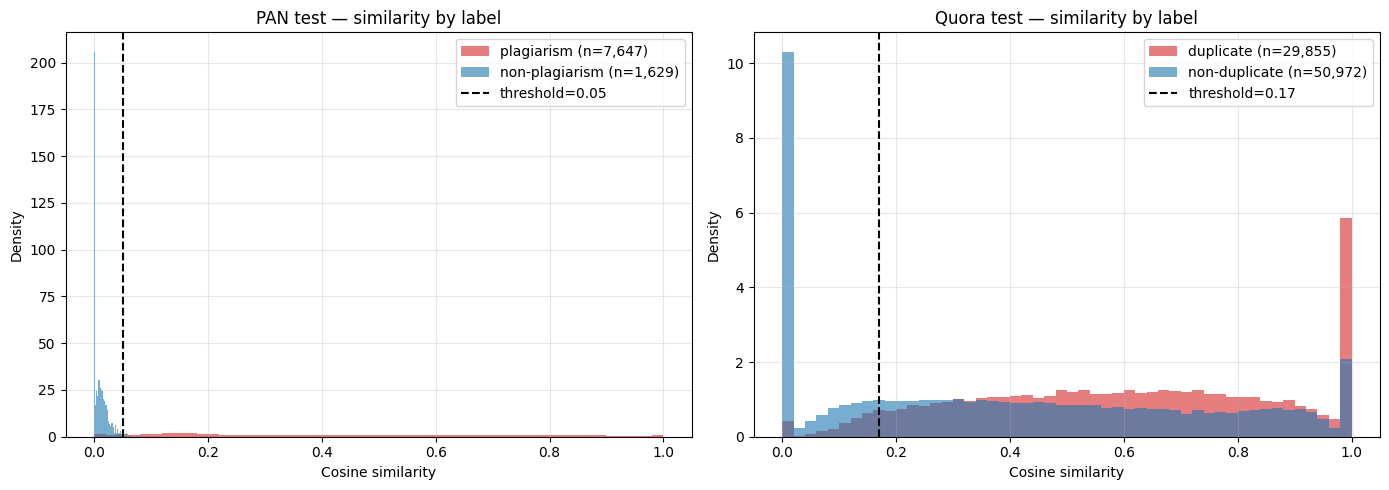

In [38]:
# Attach predictions to test dataframe
pan_test_aug = pan_test_pairs.copy()
pan_test_aug['similarity'] = pan_sims
pan_test_aug['prediction'] = pan_preds
pan_test_aug['correct']    = (pan_test_aug['prediction'] == pan_test_aug['label']).astype(int)

print('── By plagiarism_type ──')
print(pan_test_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
    'total'    : len(g),
    'pos'      : int(g['label'].sum()),
    'accuracy' : round(g['correct'].mean(), 3),
    'avg_sim'  : round(g['similarity'].mean(), 3),
})).to_string())

print('\n── By obfuscation level (positive cases only) ──')
pos_only = pan_test_aug[pan_test_aug['label'] == 1]
print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({
    'total'    : len(g),
    'detected' : int(g['prediction'].sum()),
    'recall'   : round(g['prediction'].mean(), 3),
    'avg_sim'  : round(g['similarity'].mean(), 3),
})).to_string())

# Visualization — similarity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PAN
ax = axes[0]
for label, color, name in [(1, 'tab:red', 'plagiarism'), (0, 'tab:blue', 'non-plagiarism')]:
    subset = pan_test_aug[pan_test_aug['label'] == label]
    ax.hist(subset['similarity'], bins=50, alpha=0.6,
            label=f'{name} (n={len(subset):,})', color=color, density=True)
ax.axvline(PAN_THRESHOLD, color='black', linestyle='--',
           label=f'threshold={PAN_THRESHOLD:.2f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('PAN test — similarity by label')
ax.legend()
ax.grid(alpha=0.3)

# Quora
ax = axes[1]
q_aug = q_test_pairs.copy()
q_aug['similarity'] = q_sims
q_aug['prediction'] = q_preds
for label, color, name in [(1, 'tab:red', 'duplicate'), (0, 'tab:blue', 'non-duplicate')]:
    subset = q_aug[q_aug['label'] == label]
    ax.hist(subset['similarity'], bins=50, alpha=0.6,
            label=f'{name} (n={len(subset):,})', color=color, density=True)
ax.axvline(Q_THRESHOLD, color='black', linestyle='--',
           label=f'threshold={Q_THRESHOLD:.2f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Quora test — similarity by label')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model1_distributions.png', dpi=120)
plt.show()

## 11. Save model + threshold

In [41]:
joblib.dump({
    'vectorizer': vectorizer,
    'threshold' : BEST_THRESHOLD,
}, MODELS_DIR / 'model1_tfidf.joblib')

print(f'Saved → {MODELS_DIR / "model1_tfidf.joblib"}')
print(f'Threshold: {BEST_THRESHOLD}')
print('\n── Final summary ──')
print(results_df.to_string(index=False))

Saved → trained_models/model1_tfidf.joblib
Threshold: 0.05

── Final summary ──
   dataset     n  accuracy  precision   recall       f1  roc_auc  threshold
  PAN test  9276  0.946313   0.997218 0.937492 0.966433 0.982202       0.05
Quora test 80827  0.544311   0.444956 0.944565 0.604943 0.682224       0.17


## Done ✅

**What this baseline tells us:**
- Strong performance on `none` and `low` obfuscation = TF-IDF crushes near-verbatim copies
- Weaker on `high` obfuscation and `translation` = these need semantic models
- This is the bar Models 2 (LSTM Siamese) and 3 (SBERT) must beat

**Next:** Model 2 — Word2Vec/GloVe + Bi-LSTM Siamese network (PyTorch, A100 friendly).